In [25]:
import os
import yaml

# Set the base directory and the layer to analyze
base_dir = './alexnet_128/outputs'
layer_index = 0  # Change this to target a different layer
folder = os.path.join(base_dir, str(layer_index))
ert_path = os.path.join(folder, 'timeloop-mapper.ERT_summary.yaml')

# Check if file exists
if not os.path.isfile(ert_path):
    print(f"Error: {ert_path} not found.")
else:
    with open(ert_path, 'r') as file:
        ert_data = yaml.safe_load(file)

    # Accumulate energy per component
    component_energy = {}
    for component in ert_data.get('ERT_summary', {}).get('table_summary', []):
        name = component['name']
        total_energy = sum(action['energy'] for action in component.get('actions', []))
        component_energy[name] = total_energy

    # Sort components by energy descending
    total_layer_energy = sum(component_energy.values())
    sorted_components = sorted(component_energy.items(), key=lambda x: -x[1])

    # Store and print results with percentages
    component_energy_percent = {}
    print(f"\nLayer {layer_index} - Total Energy: {total_layer_energy:.6f} uJ\n")
    for name, energy in sorted_components:
        percent = (energy / total_layer_energy) * 100 if total_layer_energy > 0 else 0
        component_energy_percent[name] = percent
        print(f"{name:<35} : {energy:.6f} uJ ({percent:.2f}%)")

    # Now component_energy_percent is ready for plotting (e.g., pie chart)



Layer 0 - Total Energy: 1557.450682 uJ

system_top_level.DRAM[1..1]         : 1536.000000 uJ (98.62%)
system_top_level.shared_glb[1..1]   : 19.787093 uJ (1.27%)
system_top_level.pe_spad[1..16384]  : 0.672762 uJ (0.04%)
system_top_level.mac[1..16384]      : 0.670367 uJ (0.04%)
system_top_level.weight_reg[1..16384] : 0.106820 uJ (0.01%)
system_top_level.input_activation_reg[1..16384] : 0.106820 uJ (0.01%)
system_top_level.output_activation_reg[1..16384] : 0.106820 uJ (0.01%)


In [6]:
import os

def extract_outputs(model, arch):
    output_dir = os.path.join(".", arch, "outputs")
    print(f"Scanning in: {output_dir}")
    print("Model \t Folder \tEnergy (J) \tCycles")

    total_energy = 0.0
    total_cycles = 0.0
    total_area = 0.0

    layer_data = []  # For plotting

    for subfolder in sorted(os.listdir(output_dir)):
        sub_path = os.path.join(output_dir, subfolder)
        if not os.path.isdir(sub_path):
            continue

        stat_file = os.path.join(sub_path, "timeloop-mapper.stats.txt")
        art_file = os.path.join(sub_path, "timeloop-mapper.ART.yaml")

        folder_energy = 0.0
        folder_cycles = 0.0

        try:
            with open(stat_file, 'r') as f:
                for line in f:
                    if line.startswith("Energy:"):
                        folder_energy = float(line.split()[1])  # uJ
                    elif line.startswith("Cycles:"):
                        folder_cycles = float(line.split()[1])
        except FileNotFoundError:
            print(f"Warning: Missing {stat_file}")
            continue

        total_energy += folder_energy
        total_cycles += folder_cycles

        # Area only once
        if total_area == 0:
            try:
                with open(art_file, 'r') as f:
                    lines = f.readlines()
                    names = [l for l in lines if 'name' in l]
                    areas = [l for l in lines if 'area' in l]
                    for name_line, area_line in zip(names, areas):
                        count = float(name_line.split('..')[1].replace(']', '').strip())
                        area_per_unit = float(area_line.split(': ')[1].strip())
                        total_area += count * area_per_unit
            except FileNotFoundError:
                print(f"Warning: Missing {art_file}")

        print(f"{model} \t {subfolder} \t{folder_energy * 1e-6:.2e} \t{int(folder_cycles)}")

        # Save for plotting
        layer_data.append({
            "Layer": int(subfolder),
            "Energy (uJ)": folder_energy,
            "Cycles": folder_cycles
        })

    # Summary
    total_energy *= 1e-6
    total_area *= 1e-6
    throughput = 1 / (total_cycles * 1e-9) if total_cycles > 0 else 0

    print("\n=== Total Summary ===")
    print("Model \t\tEnergy/inference (J) \tArea (mm²) \tThroughput (inf/s)")
    print("{:s} \t{:.2e} \t\t{:.2f} \t\t{:.2e}".format(model, total_energy, total_area, throughput))

    return layer_data


In [7]:
import matplotlib.pyplot as plt
import pandas as pd

def plot_energy_and_cycles_per_layer(layer_data):
    df = pd.DataFrame(layer_data).sort_values("Layer")

    # Plot Energy
    plt.figure(figsize=(10, 5))
    plt.bar(df["Layer"], df["Energy (uJ)"], color='mediumseagreen')
    plt.title("Energy per Layer")
    plt.xlabel("Layer")
    plt.ylabel("Energy (uJ)")
    plt.xticks(df["Layer"])
    plt.tight_layout()
    plt.show()

    # Plot Cycles
    plt.figure(figsize=(10, 5))
    plt.bar(df["Layer"], df["Cycles"], color='steelblue')
    plt.title("Cycles per Layer")
    plt.xlabel("Layer")
    plt.ylabel("Cycles")
    plt.xticks(df["Layer"])
    plt.tight_layout()
    plt.show()


Scanning in: ./alexnet_128/outputs
Model 	 Folder 	Energy (J) 	Cycles
alexnet 	 0 	1.85e-04 	1585176
alexnet 	 1 	4.86e-04 	2615652
alexnet 	 2 	2.74e-04 	876096
alexnet 	 3 	3.91e-04 	1749488
alexnet 	 4 	2.41e-04 	1165424
alexnet 	 5 	4.89e-03 	294912
alexnet 	 6 	2.17e-03 	131072
alexnet 	 7 	5.31e-04 	32000

=== Total Summary ===
Model 		Energy/inference (J) 	Area (mm²) 	Throughput (inf/s)
alexnet 	9.17e-03 		15.43 		1.18e+02


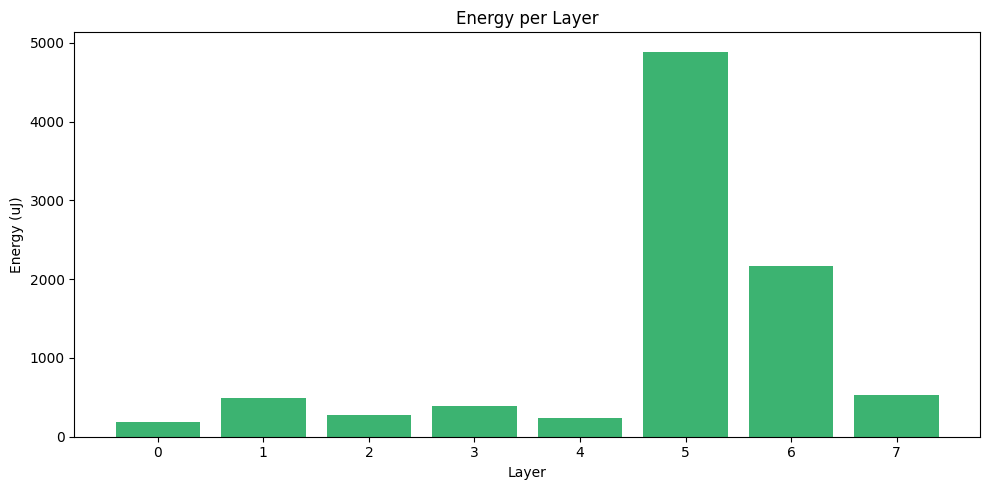

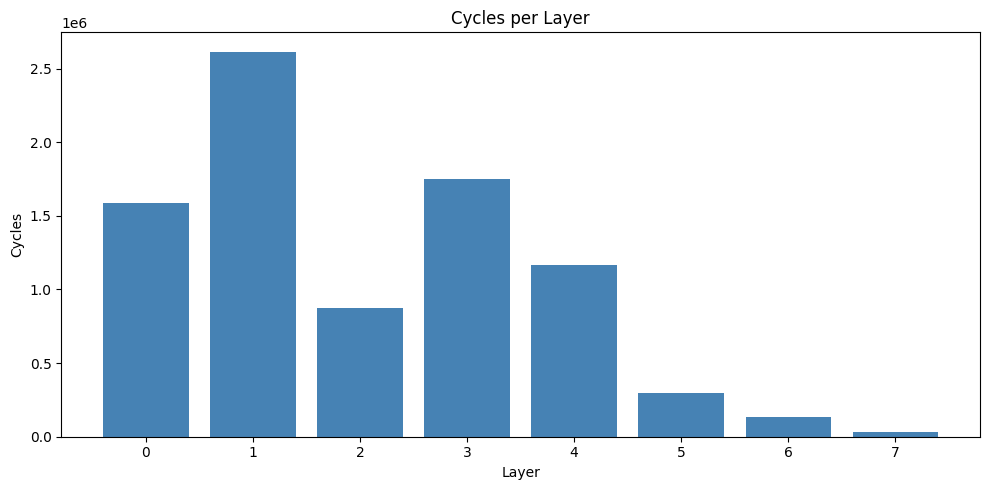

In [8]:
layer_data = extract_outputs("alexnet", "alexnet_128")
plot_energy_and_cycles_per_layer(layer_data)

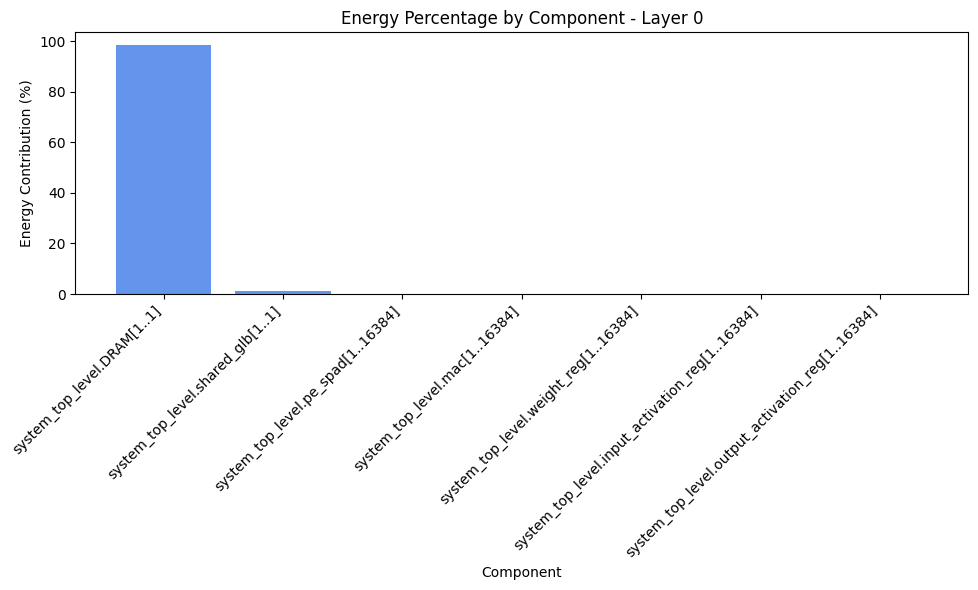

In [13]:
import matplotlib.pyplot as plt

# Bar chart of energy percentage per component
components = list(component_energy_percent.keys())
percentages = list(component_energy_percent.values())

plt.figure(figsize=(10, 6))
plt.bar(components, percentages, color='cornflowerblue')
plt.ylabel('Energy Contribution (%)')
plt.xlabel('Component')
plt.title(f'Energy Percentage by Component - Layer {layer_index}')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()



In [15]:
for entry in layer_data:
    print(f"Layer {entry['Layer']} - Energy: {entry['Energy (uJ)']:.2f} uJ")

Layer 0 - Energy: 184.73 uJ
Layer 1 - Energy: 486.26 uJ
Layer 2 - Energy: 274.25 uJ
Layer 3 - Energy: 390.63 uJ
Layer 4 - Energy: 240.87 uJ
Layer 5 - Energy: 4888.72 uJ
Layer 6 - Energy: 2172.60 uJ
Layer 7 - Energy: 530.88 uJ


In [18]:
layer_data

[{'Layer': 0, 'Energy (uJ)': 184.73, 'Cycles': 1585176.0},
 {'Layer': 1, 'Energy (uJ)': 486.26, 'Cycles': 2615652.0},
 {'Layer': 2, 'Energy (uJ)': 274.25, 'Cycles': 876096.0},
 {'Layer': 3, 'Energy (uJ)': 390.63, 'Cycles': 1749488.0},
 {'Layer': 4, 'Energy (uJ)': 240.87, 'Cycles': 1165424.0},
 {'Layer': 5, 'Energy (uJ)': 4888.72, 'Cycles': 294912.0},
 {'Layer': 6, 'Energy (uJ)': 2172.6, 'Cycles': 131072.0},
 {'Layer': 7, 'Energy (uJ)': 530.88, 'Cycles': 32000.0}]

In [20]:
percentages

[98.6227055631361,
 1.2704795813978649,
 0.0431963286189733,
 0.043042594409068914,
 0.0068586441459988256,
 0.0068586441459988256,
 0.0068586441459988256]

In [21]:
per_layer_component_energy = []

for entry in layer_data:
    energy = entry["Energy (uJ)"]
    layer_result = {
        "Layer": entry["Layer"]
    }
    for i, pct in enumerate(percentages):
        comp_energy = energy * (pct / 100)
        layer_result[components[i]] = comp_energy
    per_layer_component_energy.append(layer_result)

# Print result for one layer as an example
import pandas as pd
df = pd.DataFrame(per_layer_component_energy)
print(df)

   Layer  system_top_level.DRAM[1..1]  system_top_level.shared_glb[1..1]  \
0      0                   182.185724                           2.346957   
1      1                   479.562768                           6.177834   
2      2                   270.472770                           3.484290   
3      3                   385.249875                           4.962874   
4      4                   237.552511                           3.060204   
5      5                  4821.387931                          62.110189   
6      6                  2142.676901                          27.602439   
7      7                   523.568219                           6.744722   

   system_top_level.pe_spad[1..16384]  system_top_level.mac[1..16384]  \
0                            0.079797                        0.079513   
1                            0.210046                        0.209299   
2                            0.118466                        0.118044   
3                      

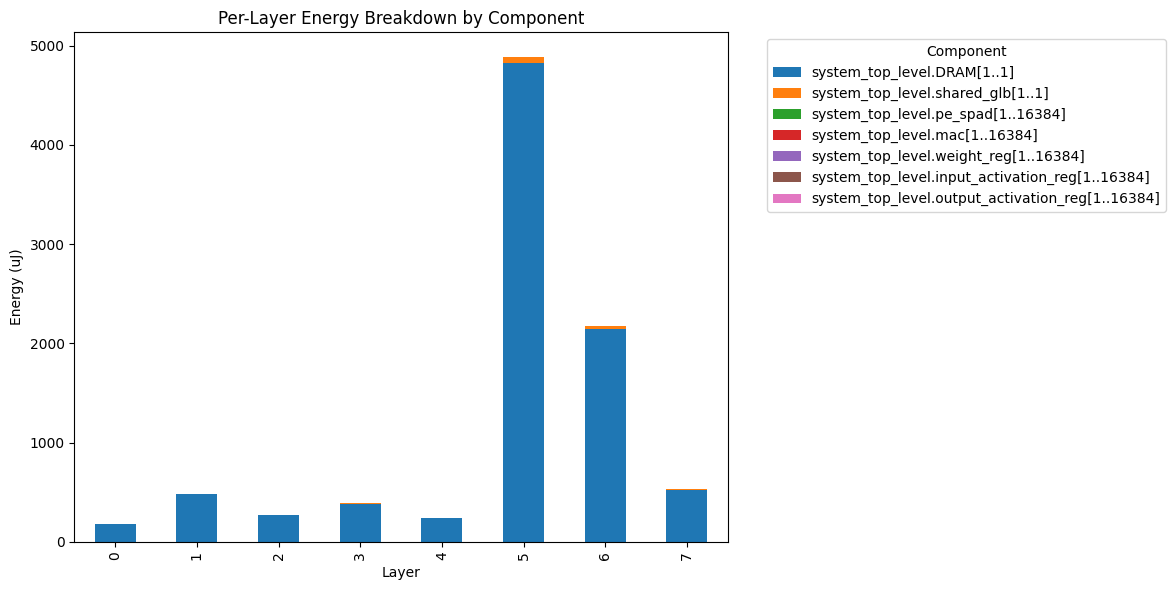

In [22]:
import matplotlib.pyplot as plt

# Assume df is already created as in previous step
# Columns: 'Layer', 'Comp0', 'Comp1', ..., 'CompN'

# Set 'Layer' as index so the components are columns
df_plot = df.set_index('Layer')

# Plot
ax = df_plot.plot(kind='bar', stacked=True, figsize=(12, 6))

plt.title("Per-Layer Energy Breakdown by Component")
plt.xlabel("Layer")
plt.ylabel("Energy (uJ)")
plt.legend(title="Component", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()
